# Plotting results

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

# If the notebook is inside configs/, go one level up.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts import plots_solver as ps


In [2]:
from scripts import plots_solver as ps

runs = ps.load_all_runs_matching(
    results_dir="results/runs/dense",
    pattern="hybrid_saved_*",
)

run = runs[sorted(runs)[-1]]

cbe_data, cbe_meta = ps.load_cbe_solution("results/runs/cbe_benchmark")
cbe = ps.make_cbe_interpolators(cbe_data)
cosmo = ps.make_cosmology()

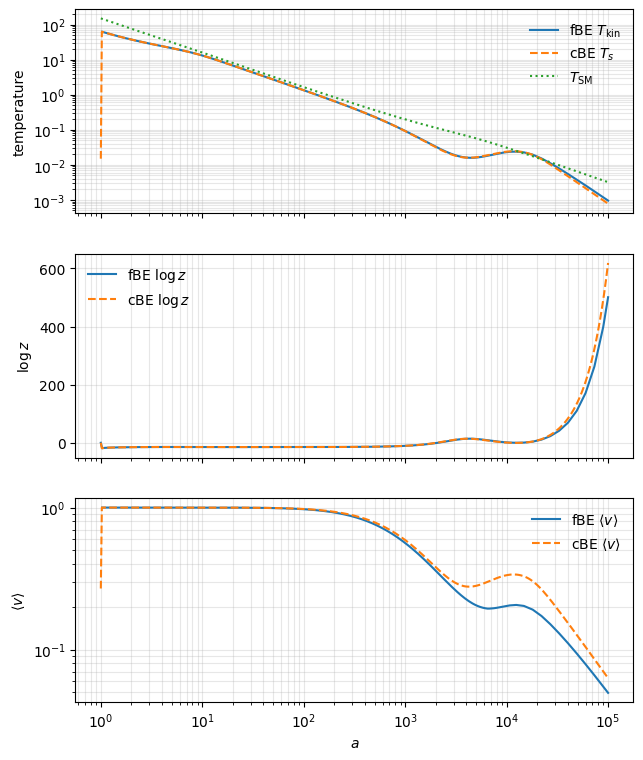

In [3]:
fig, diag = ps.plot_temperature_fugacity_velocity(
    run,
    cbe=cbe,
    cosmo=cosmo,
    velocity_quantity="avg_v",
)


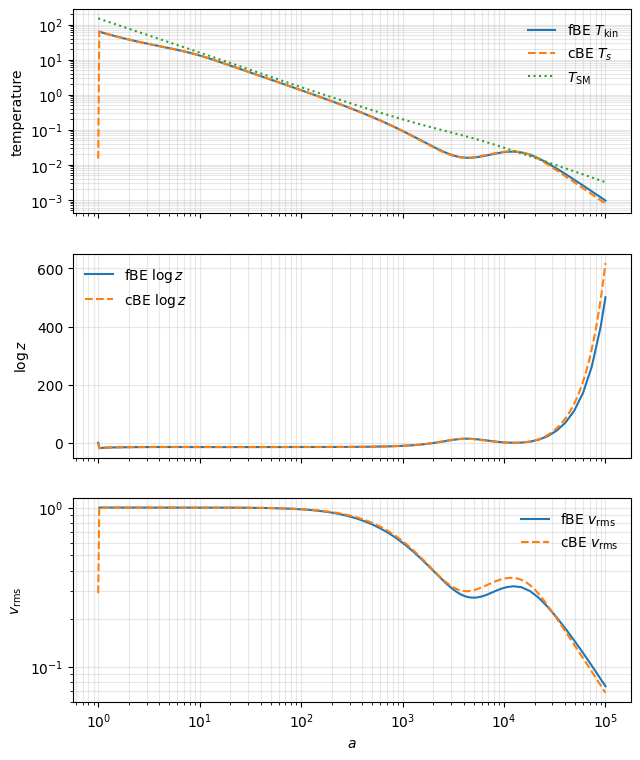

In [4]:
fig, diag = ps.plot_temperature_fugacity_velocity(
    run,
    cbe=cbe,
    cosmo=cosmo,
    velocity_quantity="v_rms",)

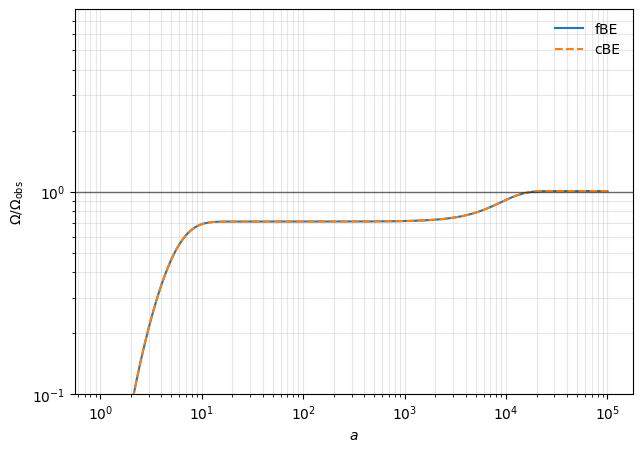

In [5]:
fig, diag = ps.plot_omega_evolution(
    run,
    cbe_solution=(cbe_data, cbe_meta),
    cosmo=cosmo,
)



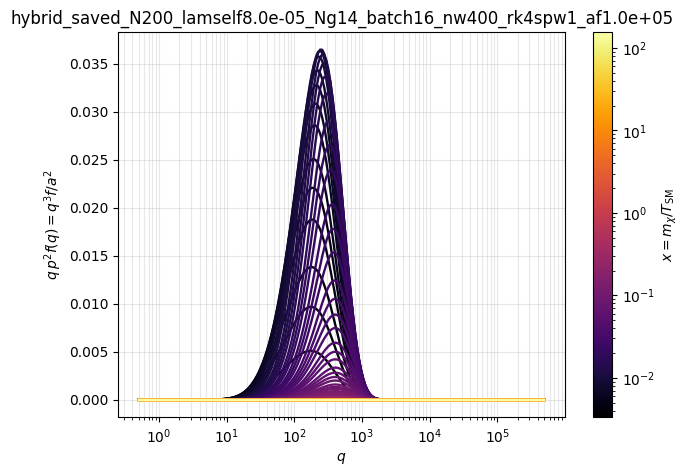

In [6]:
ax = ps.plot_snapshots_evolution(
    run,
    quantity="q_p2f",
    color_by="x",
    cmap="inferno",
    max_curves=100,
)



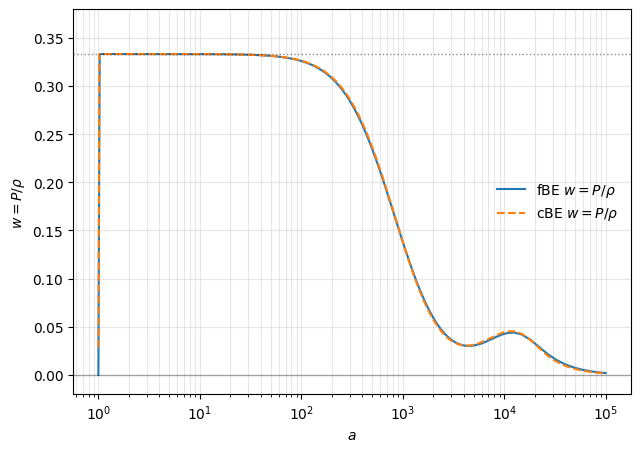

In [7]:
ax, diag = ps.plot_equation_of_state(
    run,
    cbe=cbe,
)



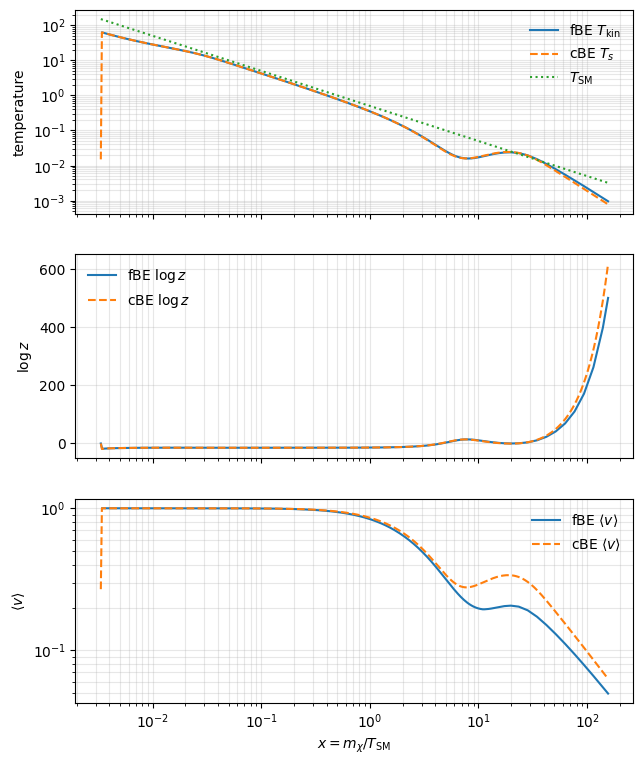

In [8]:
fig, diag = ps.plot_temperature_fugacity_velocity_x(
    run,
    cbe=cbe,
    cosmo=cosmo,
    velocity_quantity="avg_v",
)


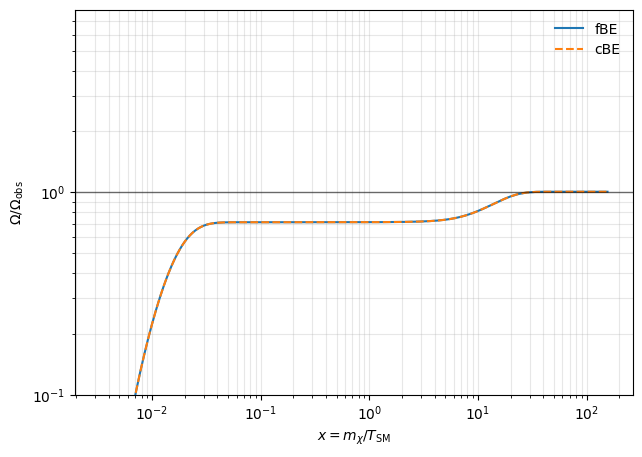

In [9]:
ax, diag = ps.plot_omega_evolution_x(
    run,
    cbe_solution=(cbe_data, cbe_meta),
    cosmo=cosmo,
)


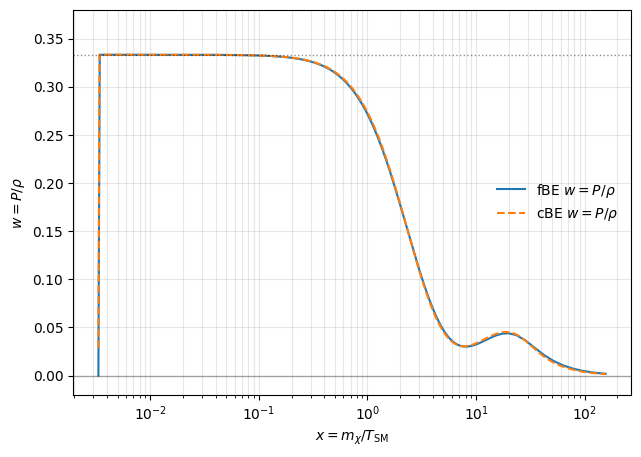

In [10]:
ax, diag = ps.plot_equation_of_state_x(
    run,
    cbe=cbe,
    cosmo=cosmo,
)

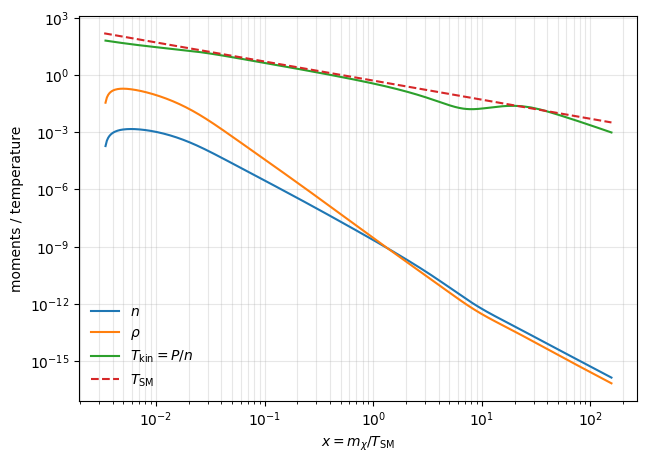

In [11]:
ax, moments = ps.plot_moment_evolution_x(
    run,
    cosmo=cosmo,
)

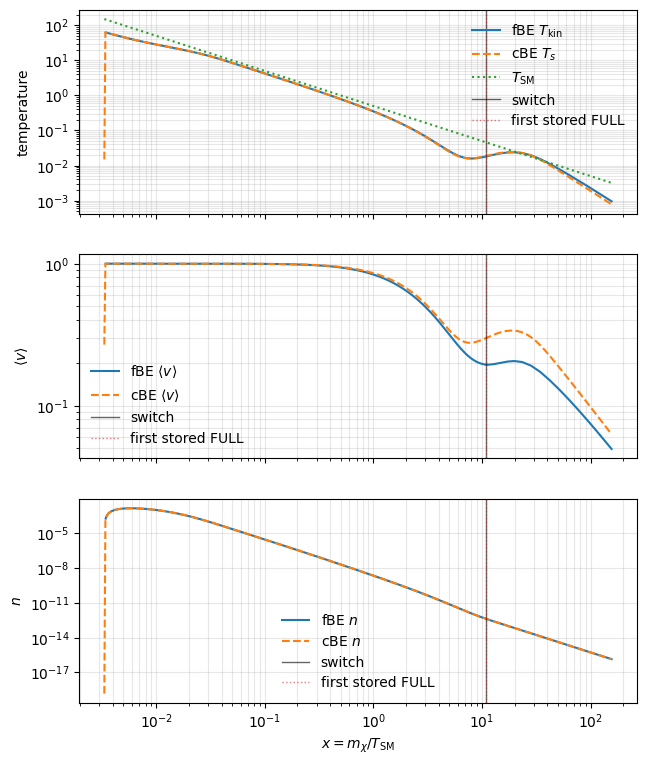

In [12]:
fig, summary = ps.plot_scattering_switch_diagnostics_x(
    run,
    cbe=cbe,
    cosmo=cosmo,
)

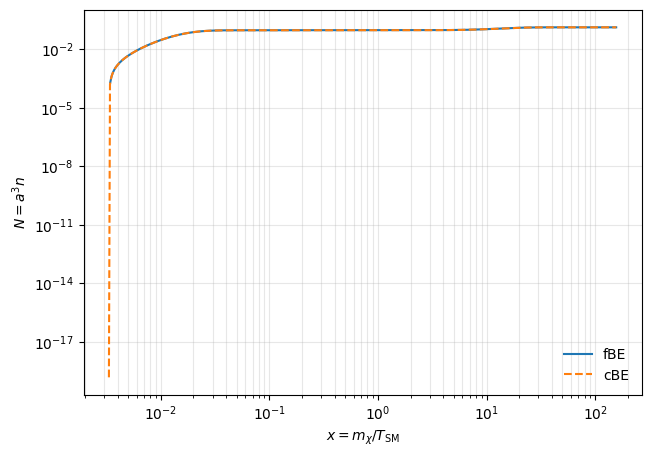

In [13]:
ax, diag = ps.plot_comoving_number_evolution_x(
    run,
    cbe_solution=(cbe_data, cbe_meta),
    cosmo=cosmo,
)


fBE inferred MB:
  a      = 1.000000e+05
  Tkin   = 9.558097e-04
  n      = 1.364803e-16
  log z  = 5.008087e+02
cBE:
  T      = 7.805218e-04
  N      = 1.364463e-01
  n      = 1.364463e-16
  log z  = 6.185934e+02
Final velocity / moment summary:
  a       = 1.000000e+05
  n       = 1.364803e-16
  rho     = 6.843734e-17
  P       = 1.304492e-19
  w=P/rho = 1.906111e-03
  Tkin    = 9.558097e-04
  avg_p   = 2.503772e-02
  avg_v   = 4.961296e-02
  v_rms   = 7.514171e-02


{'idx': -1,
 'a': 100000.00000000001,
 'q_grid_max': 499999.99999999994,
 'active_qmax': 38317.054340037226,
 'active_qmax_over_grid_qmax': 0.07663410868007446,
 'negative_points': 0,
 'finite': True,
 'y_abs_max': 8.517035779510832e-11}

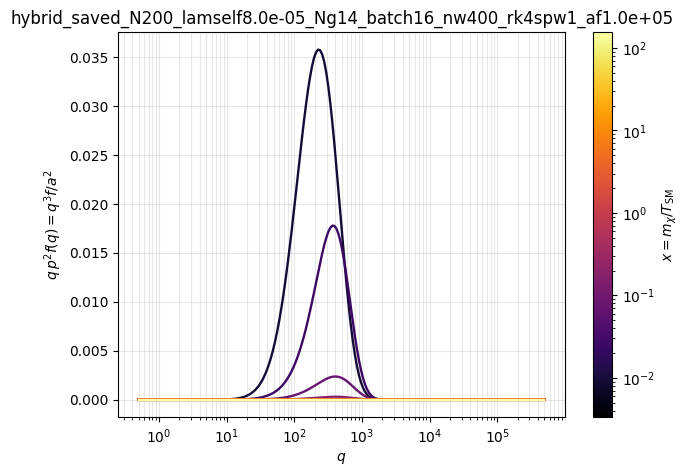

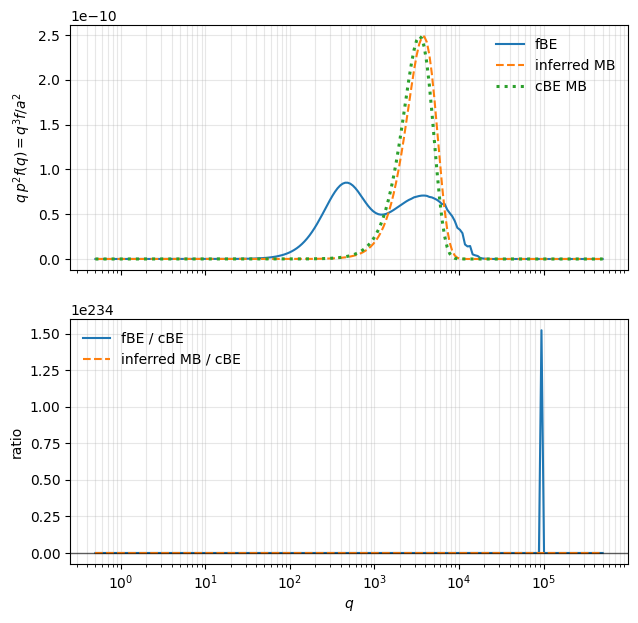

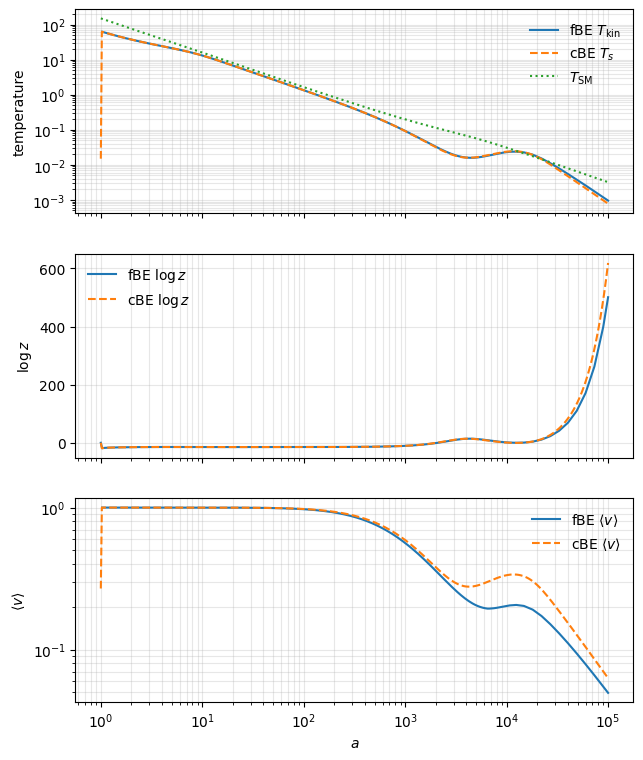

In [14]:
from scripts import plots_solver as ps

runs = ps.load_all_runs_matching(
    results_dir="results/runs/dense",
    pattern="hybrid_saved_*",
)

cbe_data, cbe_meta = ps.load_cbe_solution("results/runs/cbe_benchmark")
cbe = ps.make_cbe_interpolators(cbe_data)

run = runs[sorted(runs)[-1]]

ps.plot_snapshots_evolution(
    run,
    n_snapshots=10,
    quantity="q_p2f",
    color_by="x",
    cmap="inferno",
)

ps.plot_final_against_cbe(
    run,
    cbe=cbe,
    quantity="q_p2f",
    yscale="linear",
)

ps.plot_temperature_fugacity_velocity(
    run,
    cbe=cbe,
    cosmo=ps.make_cosmology(),
)

ps.print_final_velocity_summary(run)
ps.tail_diagnostics(run)
